Title: capacity_data_solar_all_yearly.ipynb

Purpose: Transform the xml solar capacity data into a gridded format for each year separately

Author: Onno Nennecke on 11.12.2025 Modified: 16.12.2025

Input data: 

- Original MaStR solar data in xml format
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/EinheitenSolar_*.xml'

Output data:

- Capacity data Nettoleistung 2015-2024
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_{year}.nc'

In [1]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
import os
import sys
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
# Define the directory containing the XML files
directory = '/climca/people/onennecke/Wind_Solar_MaStR/'

# List all XML files in the directory
xml_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.startswith('EinheitenSolar')]
# xml_files[0:3]

Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'AnzahlModule', 'Inbetriebnahmedatum', 'Lage', 'Gemeinde', 'Laengengrad', 'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Ort',
       'Registrierungsdatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart',
       'ZugeordneteWirkleistungWechselrichter', 'Leistungsbegrenzung',
       'EinheitlicheAusrichtungUndNeigungswinkel', 'Hauptausrichtung',
       'HauptausrichtungNeigungswinkel', 'Nutzungsbereich', 'EegMaStRNummer',
       'Nebenausrichtung', 'NebenausrichtungNeigungswinkel',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 'InAnspruchGenommeneFlaeche',
       'ArtDerFlaecheIds', 'DatumEndgueltigeStilllegung', 'InAnspruchGenommeneAckerflaeche',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'Hausnummer', 'HausnummerNichtGefunden','Gemeindeschluessel']

In [3]:

# Initialize an empty list to store data from all files
all_data = []

# Iterate over the list of XML files and process each file
for xml_file in xml_files:
    # Load the XML file
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    # Extract data from the XML file (example extraction, adjust as needed)
    for einheit in root.findall('EinheitSolar'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Postleitzahl': einheit.find('Postleitzahl').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'AnzahlModule': int(einheit.find('AnzahlModule').text) if einheit.find('AnzahlModule') is not None else np.nan,
            'Inbetriebnahmedatum': einheit.find('Inbetriebnahmedatum').text if einheit.find('Inbetriebnahmedatum') is not None else np.nan,
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'Gemeinde': einheit.find('Gemeinde').text if einheit.find('Gemeinde') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text),
            'Land': int(einheit.find('Land').text)
        }
        all_data.append(einheit_data)

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)

# Display the resulting DataFrame
print(df)

        EinheitMastrNummer Postleitzahl  Bruttoleistung  Nettonennleistung  \
0          SEE939449959979        77746            0.60               0.60   
1          SEE981231454889        54455            9.72               9.72   
2          SEE906116213009        28197            3.78               3.78   
3          SEE933206179068        63762            0.80               0.80   
4          SEE900597885892        91058            6.02               6.00   
...                    ...          ...             ...                ...   
4869169    SEE957586860187        38126           17.10              12.00   
4869170    SEE990188338449        97440            0.60               0.60   
4869171    SEE991049073868        07749            0.60               0.60   
4869172    SEE981519448777        71642            1.00               0.80   
4869173    SEE921139661972        44867            0.86               0.80   

         AnzahlModule Inbetriebnahmedatum    Lage      Gemeinde

In [4]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_0 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb


# Drop units without an Inbetriebnahmedatum and an Inbetriebnahmedatum of 2025 or later
print(len(df_0[df_0['Inbetriebnahmedatum'].isna()]))
df_01 = df_0[~df_0['Inbetriebnahmedatum'].isna()].copy()

print(len(df_01[df_01['Inbetriebnahmedatum'] >= '2025-01-01']))
df_1 = df_01[df_01['Inbetriebnahmedatum'] < '2025-01-01'].copy()

# Drop units which are not in Germany (There seem to be very rare international units in the dataset)
print(len(df_1[df_1['Land'] != 84]))
df_2 = df_1[df_1['Land'] == 84].copy() # 84 == Deutschland

# Drop columns EinheitBetriebsstatus and Land as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Land'], inplace=True)

90112
10
3
16


In [5]:
df_2['Nettonennleistung'].sum()

np.float64(88379230.05000003)

In [6]:
# df_2014 = df_2[(df_2['Inbetriebnahmedatum'] <= '2014-12-31')].copy()
df_2015 = df_2[(df_2['Inbetriebnahmedatum'] <= '2015-12-31')].copy()
df_2016 = df_2[(df_2['Inbetriebnahmedatum'] <= '2016-12-31')].copy()
df_2017 = df_2[(df_2['Inbetriebnahmedatum'] <= '2017-12-31')].copy()
df_2018 = df_2[(df_2['Inbetriebnahmedatum'] <= '2018-12-31')].copy()
df_2019 = df_2[(df_2['Inbetriebnahmedatum'] <= '2019-12-31')].copy()
df_2020 = df_2[(df_2['Inbetriebnahmedatum'] <= '2020-12-31')].copy()
df_2021 = df_2[(df_2['Inbetriebnahmedatum'] <= '2021-12-31')].copy()
df_2022 = df_2[(df_2['Inbetriebnahmedatum'] <= '2022-12-31')].copy()
df_2023 = df_2[(df_2['Inbetriebnahmedatum'] <= '2023-12-31')].copy()
df_2024 = df_2[(df_2['Inbetriebnahmedatum'] <= '2024-12-31')].copy()

In [7]:
print('2015: ', df_2015['Nettonennleistung'].sum() / 1e6)
print('2016: ', df_2016['Nettonennleistung'].sum() / 1e6)
print('2017: ', df_2017['Nettonennleistung'].sum() / 1e6)
print('2018: ', df_2018['Nettonennleistung'].sum() / 1e6)
print('2019: ', df_2019['Nettonennleistung'].sum() / 1e6)
print('2020: ', df_2020['Nettonennleistung'].sum() / 1e6)
print('2021: ', df_2021['Nettonennleistung'].sum() / 1e6)
print('2022: ', df_2022['Nettonennleistung'].sum() / 1e6)
print('2023: ', df_2023['Nettonennleistung'].sum() / 1e6)
print('2024: ', df_2024['Nettonennleistung'].sum() / 1e6)

2015:  35.90600653200001
2016:  37.23903762499997
2017:  38.72372957699998
2018:  41.34738969899999
2019:  44.94097179499996
2020:  49.524734608
2021:  54.562384967999996
2022:  61.204401046999976
2023:  74.59000770899996
2024:  88.37923005000003


In [8]:
# Read CSV data
SMARD_data = pd.read_csv('/home/onennecke/SMARD_data/Installierte_Erzeugungsleistung_201501010000_202501010000_Jahr.csv', sep=';')

# Add this line of data to the panda: 01.01.2025, 00:00 	01.01.2026, 00:00 	9.215,00 	63.192,00 	86.408,00 
SMARD_data.loc[len(SMARD_data)] = ['01.01.2025', '01.01.2026', '9.215,00', '63.192,00', '86.408,00']

# Remove the first row (2014 data)
SMARD_data = SMARD_data.iloc[1:].reset_index(drop=True)

# Remove wind columns
SMARD_data = SMARD_data.drop(columns=['Wind Offshore [MW] Originalauflösungen', 'Wind Onshore [MW] Originalauflösungen', 'Datum von', 'Datum bis'])

# Rename solar column
SMARD_data = SMARD_data.rename(columns={'Photovoltaik [MW] Originalauflösungen': 'Solar [MW] - SMARD'})

# Convert solar column to float
SMARD_data['Solar [MW] - SMARD'] = SMARD_data['Solar [MW] - SMARD'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Add year column in the beginning
SMARD_data.insert(0, 'Year', range(2015, 2025))
SMARD_data

,Year,Solar [MW] - SMARD
0,2015,38686.0
1,2016,40834.0
2,2017,42804.0
3,2018,44036.0
4,2019,47754.0
5,2020,50410.0
6,2021,57744.0
7,2022,63066.0
8,2023,76601.0
9,2024,86408.0


In [9]:
# Read CSV data
EC_data = pd.read_csv('/home/onennecke/SMARD_data/energy-charts_Installierte_Netto-Leistung_zur_Stromerzeugung_in_Deutschland.csv', sep=',')

# # Remove the first row (2014 data)
EC_data = EC_data.iloc[14:].reset_index(drop=True)

# # Remove wind columns
EC_data = EC_data.drop(columns=['Wind offshore', 'Wind onshore', 'Jahr'])

# # Rename solar column
EC_data = EC_data.rename(columns={'Solar AC': 'Solar [MW] - EC'})

# # Convert solar column to float
EC_data['Solar [MW] - EC'] = EC_data['Solar [MW] - EC'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Correct an error
EC_data.loc[7, 'Solar [MW] - EC'] = EC_data.loc[7, 'Solar [MW] - EC'] * 10

# # Add year column in the beginning
# EC_data.insert(0, 'Year', range(2015, 2025))
EC_data

,Solar [MW] - EC
0,36986.0
1,38349.0
2,39884.0
3,42596.0
4,46252.0
5,50936.0
6,56083.0
7,62920.0
8,76873.0
9,92333.0


In [10]:
# Add this to SMARD_data
MASTR_data = [df_2015['Nettonennleistung'].sum() / 1e3, df_2016['Nettonennleistung'].sum() / 1e3, df_2017['Nettonennleistung'].sum() / 1e3, df_2018['Nettonennleistung'].sum() / 1e3,
              df_2019['Nettonennleistung'].sum() / 1e3, df_2020['Nettonennleistung'].sum() / 1e3, df_2021['Nettonennleistung'].sum() / 1e3, df_2022['Nettonennleistung'].sum() / 1e3,
              df_2023['Nettonennleistung'].sum() / 1e3, df_2024['Nettonennleistung'].sum() / 1e3]
MASTR_data

SMARD_data['MASTR'] = MASTR_data

SMARD_data['EC'] = EC_data['Solar [MW] - EC']

SMARD_data['Difference SMARD - MASTR'] = SMARD_data['Solar [MW] - SMARD'] - SMARD_data['MASTR']

SMARD_data

,Year,Solar [MW] - SMARD,MASTR,EC,Difference SMARD - MASTR
0,2015,38686.0,35906.006532,36986.0,2779.993468
1,2016,40834.0,37239.037625,38349.0,3594.962375
2,2017,42804.0,38723.729577,39884.0,4080.270423
3,2018,44036.0,41347.389699,42596.0,2688.610301
4,2019,47754.0,44940.971795,46252.0,2813.028205
5,2020,50410.0,49524.734608,50936.0,885.265392
6,2021,57744.0,54562.384968,56083.0,3181.615032
7,2022,63066.0,61204.401047,62920.0,1861.598953
8,2023,76601.0,74590.007709,76873.0,2010.992291
9,2024,86408.0,88379.230050,92333.0,-1971.230050


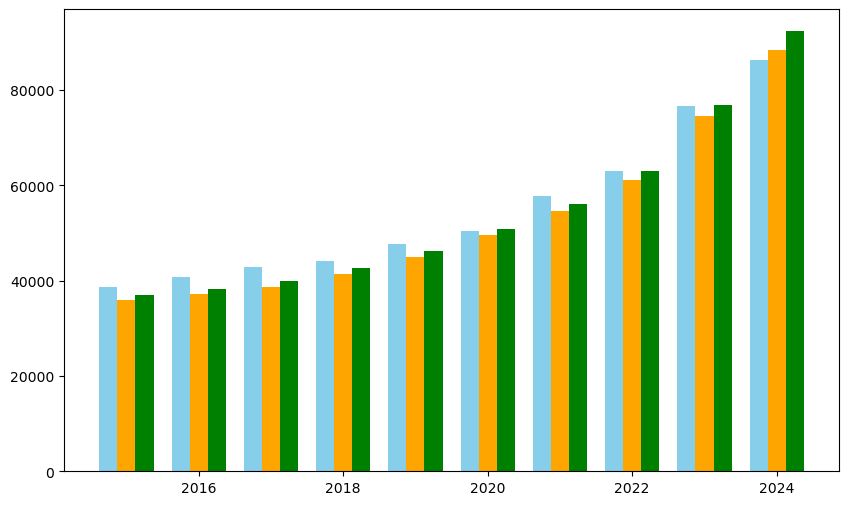

In [11]:
# Plot the data in a grouped bar chart
x = SMARD_data['Year']
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, SMARD_data['Solar [MW] - SMARD'], width, label='SMARD', color='skyblue')
bars2 = ax.bar(x, SMARD_data['MASTR'], width, label='MaStR', color='orange')
bars3 = ax.bar(x + width, SMARD_data['EC'], width, label='EC', color='green')

In [12]:
# Create centroids
# Lade eine Shapefile mit PLZ-Geometrien (z.B. aus OpenStreetMap oder von Statistikbehörden)
plz_shp = gpd.read_file("/climca/people/onennecke/PLZ_Germany/OSM_PLZ.shp")

# Daten mit PLZ-Zentroiden verknüpfen
plz_shp["geometry"] = plz_shp.geometry.centroid

# Reproject data
gdf_latlong = plz_shp.to_crs(epsg=4326)

# print(gdf_latlong.crs)

gdf_latlong['x'] = gdf_latlong['geometry'].x
gdf_latlong['y'] = gdf_latlong['geometry'].y
gdf_latlong

plz_df = gdf_latlong[["plz", "geometry", "x", "y"]]
plz_df

,plz,geometry,x,y
0,64743,POINT (8.98561 49.6067),8.985609,49.606698
1,81248,POINT (11.40315 48.14827),11.403147,48.148274
2,60315,POINT (8.67392 50.1123),8.673919,50.112304
3,99331,POINT (10.82683 50.71362),10.826825,50.713624
4,60312,POINT (8.67302 50.11155),8.673024,50.111553
...,...,...,...,...
8165,63874,POINT (9.34342 49.86497),9.343419,49.864974
8166,63856,POINT (9.26131 49.96501),9.261309,49.965013
8167,63869,POINT (9.35162 50.03609),9.351621,50.036092
8168,75339,POINT (8.57751 48.80104),8.577507,48.801035


In [13]:
list_plz_nd = set(df_2["Postleitzahl"]) - set(plz_df["plz"])    # These PLZs are not in the PLZ shapefile

print('There are', len(set(df_2["Postleitzahl"])), 'unique plz in the dataset. \n', 
    'There are', len(set(plz_df["plz"])), 'PLZs in the reference PLZ shapefile. \n',
    len(list_plz_nd), 'of the plzs in the dataset are not in the PLZ shapefile --> Outdated \n',
    'These are:', list_plz_nd, '\n',
    'These', len(list_plz_nd), 'plzs occur', len(df_2[df_2['Postleitzahl'].isin(list_plz_nd)]), 'times in the dataset. \n',
    'There are', len(set(plz_df["plz"]) - set(df_2["Postleitzahl"])), 'PLZs in the PLZ shapefile but not in the dataset. \n')

There are 8185 unique plz in the dataset. 
 There are 8170 PLZs in the reference PLZ shapefile. 
 22 of the plzs in the dataset are not in the PLZ shapefile --> Outdated 
 These are: {'64759', '31196', '07334', '98554', '98708', '25868', '39599', '37449', '31097', '31035', '06578', '99762', '98739', '98711', '98704', '21784', '31039', '31094', '98678', '31093', '83565', '31096'} 
 These 22 plzs occur 182 times in the dataset. 
 There are 7 PLZs in the PLZ shapefile but not in the dataset. 



In [14]:
# Replace old PLZs with new PLZs
# These PLZs exist because some are created / deleted when municipality shrink or grow

set(df_2[df_2['Postleitzahl'].isin(list_plz_nd)]['Postleitzahl'])

# Define a dictionary that maps old PLZs to new PLZs
plz_mapping = {
    '06578':'99638',
    '07334':'07333',
    '21784':'21781',
    '25868':'25879',
    '31035':'31028',
    '31039':'31028',
    '31093':'31089',
    '31094':'31089',
    '31096':'31089',
    '31097':'31195',
    '31196':'31195',
    '37449':'37445', 
    '39599':'39628',
    '64759':'64760',
    '83565':'83553',
    '98554':'98544',
    '98678':'98673',
    '98704':'98693',
    '98708':'98694',
    '98711':'98694',
    '98739':'07318',
    '99762':'99768'}

In [15]:
# Create a grid
grid = grid_func.create_ref_grid('solar_cap')
# grid

# Extract lat/lon center coordinates from the xarray grid (assumed 1D)
lat_vals = grid['lat'].values  # shape (N,)
lon_vals = grid['lon'].values  # shape (M,)

# Create 2D meshgrid of all (lat, lon) combinations
lat_mesh, lon_mesh = np.meshgrid(lat_vals, lon_vals, indexing='ij')  # shape (N, M)

# Flatten meshgrid into a (N*M, 2) array of grid point coordinates
grid_points = np.column_stack((lat_mesh.ravel(), lon_mesh.ravel()))

# Build KDTree for fast nearest neighbor search
tree = cKDTree(grid_points)

In [78]:
dfs = ['df_2015', 'df_2016', 'df_2017', 'df_2018', 'df_2019', 'df_2020', 'df_2021', 'df_2022', 'df_2023', 'df_2024']


for year, df_year in zip(range(2015, 2025), [df_2015, df_2016, df_2017, df_2018, df_2019, df_2020, df_2021, df_2022, df_2023, df_2024]):
    grouped = df_year.groupby('Postleitzahl').agg({'Bruttoleistung': 'sum', 'Nettonennleistung': 'sum', 'AnzahlModule': 'sum', 'Gemeinde': 'first'}).reset_index()
    # Replace old PLZs with new PLZs
    grouped['Postleitzahl'] = grouped['Postleitzahl'].replace(plz_mapping)


    # Group again by PLZ since some PLZs are now the doubled (faster to do it twice than to do it on all data in the beginning)
    grouped_2 = grouped.groupby('Postleitzahl').agg({'Bruttoleistung': 'sum', 'Nettonennleistung': 'sum', 'AnzahlModule': 'sum', 'Gemeinde': 'first'}).reset_index()
    
    # Merge the two DataFrames
    merged_df = pd.merge(grouped_2, plz_df, left_on='Postleitzahl', right_on='plz')

    merged_df = gpd.GeoDataFrame(merged_df, geometry=merged_df.geometry)
    merged_df.drop(columns=['plz'], inplace=True)
    # type(merged_df)
    merged_df
    
    # Gesamtleistung der Solaranlagen in Deutschland
    print('Bruttoleistung', year, ':', merged_df['Bruttoleistung'].sum())
    print('Nettonennleistung', year, ':', merged_df['Nettonennleistung'].sum())
    
    # Save current data for further use
    # merged_df.to_file(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_plz_{year}.shp')
    
    # Extract coordinates from GeoDataFrame into a (n_points, 2) array
    data_points = np.column_stack((merged_df["y"].values, merged_df["x"].values))

    # Query KDTree to find nearest grid point for each data point
    distances, flat_indices = tree.query(data_points)  # returns (distance, index)

    # Convert flat index to 2D grid indices (lat_idx, lon_idx)
    merged_df["lat_idx"], merged_df["lon_idx"] = np.unravel_index(flat_indices, lat_mesh.shape)  # shape (n_points,)

    grid_sums = merged_df.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
    grid_sums = merged_df.groupby(["lat_idx", "lon_idx"])["Nettonennleistung"].sum()
    
    # Write the sums to the grid
    for (lat_idx, lon_idx), value in grid_sums.items():
        grid[lat_idx, lon_idx] = value
        
    # Save grid as raster file
    grid.to_netcdf(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_{year}.nc')


Bruttoleistung 2015 : 39086889.048999995
Nettonennleistung 2015 : 35906006.532
Bruttoleistung 2016 : 40581285.132
Nettonennleistung 2016 : 37239037.625
Bruttoleistung 2017 : 42245580.0
Nettonennleistung 2017 : 38723729.577
Bruttoleistung 2018 : 45194791.372
Nettonennleistung 2018 : 41347389.699
Bruttoleistung 2019 : 49211274.80199999
Nettonennleistung 2019 : 44940971.794999994
Bruttoleistung 2020 : 54358218.802
Nettonennleistung 2020 : 49524734.607999995
Bruttoleistung 2021 : 60075612.783
Nettonennleistung 2021 : 54562384.968
Bruttoleistung 2022 : 67652206.335
Nettonennleistung 2022 : 61204401.047
Bruttoleistung 2023 : 82968649.75999999
Nettonennleistung 2023 : 74590007.709
Bruttoleistung 2024 : 99084291.714
Nettonennleistung 2024 : 88379230.05


In [27]:
grid_2015 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2015.nc')
grid_2024 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2024.nc')

In [30]:
grid_2015['solar_cap'].load()

<xarray.DataArray 'solar_cap' (lat: 9, lon: 10)> Size: 720B
array([[        nan,         nan,         nan,         nan,    7116.335,
           7460.656,         nan,         nan,         nan,         nan],
       [        nan,         nan,  624242.376,  792906.837, 1479088.073,
        1244661.743,  826458.539,  783085.996,         nan,         nan],
       [        nan,  364054.994,  717382.916, 1139857.243, 1262584.062,
        1313117.488, 1334534.497, 1289684.613,  125101.674,         nan],
       [ 132658.791,  620622.26 ,  698233.214,  678358.815, 1016957.294,
         817836.142,  643813.075,   14152.139,         nan,         nan],
       [ 390811.597,  716789.806,  470945.248,  592898.385,  524727.224,
         489605.052,  785929.64 ,  656925.901,  370833.983,  206933.003],
       [ 213596.581,  921766.898, 1043373.628,  842624.946,  396282.488,
         496107.634,  873572.354,  571871.316,  873284.709,  207896.514],
       [        nan,  368573.978,  911131.136,  488552.797,  219122.216,
         251088.872,  475896.645,  250572.616,  691014.638,    2647.105],
       [        nan,   36013.885,   74872.869,  465293.996,  329460.517,
         251708.228,  295541.321,  474965.6  ,  169411.37 ,         nan],
       [        nan,         nan,   10052.026,  468943.911,   84314.443,
                nan,         nan,    1781.225,    4300.459,         nan]])
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
Attributes:
    gridtype:  lonlat
    crs:       EPSG:4326

In [31]:
grid_2024['solar_cap'].load()

<xarray.DataArray 'solar_cap' (lat: 9, lon: 10)> Size: 720B
array([[        nan,         nan,         nan,         nan,   19721.008,
          16332.01 ,         nan,         nan,         nan,         nan],
       [        nan,         nan, 1496535.107, 1906078.679, 3147747.379,
        2548990.473, 1890805.471, 1605152.778,         nan,         nan],
       [        nan,  793127.477, 1600570.978, 2980158.066, 2561640.609,
        3311586.336, 3304161.658, 2489648.44 ,  266418.912,         nan],
       [ 450777.54 , 1719839.752, 1828652.176, 1847951.434, 2457679.075,
        2473780.961, 1739895.505,   41327.475,         nan,         nan],
       [1047046.707, 2663478.728, 1350381.387, 1314159.556, 1201711.344,
        1165815.979, 2277548.474, 1600561.799,  882452.257,  376164.417],
       [ 440304.028, 2293696.015, 2550199.496, 1986600.593, 1172619.431,
        1390485.142, 1769979.381, 1413236.137, 1972879.669,  322665.943],
       [        nan,  781093.683, 1922940.323, 1149332.391,  746889.971,
         761572.898, 1728297.234,  837093.062, 2073919.971,   30852.242],
       [        nan,   69240.793,  154085.853, 1061301.98 , 1356430.402,
         643288.035,  879611.934, 1122996.859,  429542.01 ,         nan],
       [        nan,         nan,   17006.308,  737576.978,  168705.786,
                nan,         nan,    6082.035,   10803.52 ,         nan]])
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
Attributes:
    gridtype:  lonlat
    crs:       EPSG:4326

In [43]:
# grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
# grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
# grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
grid_2015 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2015.nc')
grid_2016 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2016.nc')
grid_2017 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2017.nc')
grid_2018 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2018.nc')
grid_2019 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2019.nc')
grid_2020 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2020.nc')
grid_2021 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2021.nc')
grid_2022 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2022.nc')
grid_2023 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2023.nc')
grid_2024 = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_2024.nc')

In [44]:

grid_2015_sum = grid_2015['solar_cap'].sum() / 1000000
grid_2016_sum = grid_2016['solar_cap'].sum() / 1000000
grid_2017_sum = grid_2017['solar_cap'].sum() / 1000000
grid_2018_sum = grid_2018['solar_cap'].sum() / 1000000
grid_2019_sum = grid_2019['solar_cap'].sum() / 1000000
grid_2020_sum = grid_2020['solar_cap'].sum() / 1000000
grid_2021_sum = grid_2021['solar_cap'].sum() / 1000000
grid_2022_sum = grid_2022['solar_cap'].sum() / 1000000
grid_2023_sum = grid_2023['solar_cap'].sum() / 1000000
grid_2024_sum = grid_2024['solar_cap'].sum() / 1000000

In [45]:
lon_edges = grid_2024.lon.values
lat_edges = grid_2024.lat.values
# lat_edges = np.insert(lat_edges, 0, 46)


# Convert to MW
xxx1 = grid_2015['solar_cap'] / 1000000
xxx2 = grid_2016['solar_cap'] / 1000000
xxx3 = grid_2017['solar_cap'] / 1000000
xxx4 = grid_2018['solar_cap'] / 1000000
xxx5 = grid_2019['solar_cap'] / 1000000
xxx6 = grid_2020['solar_cap'] / 1000000
xxx7 = grid_2021['solar_cap'] / 1000000
xxx8 = grid_2022['solar_cap'] / 1000000
xxx9 = grid_2023['solar_cap'] / 1000000
xxx10 = grid_2024['solar_cap'] / 1000000


# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max(), xxx4.max(), xxx5.max(), xxx6.max(), xxx7.max(), xxx8.max(), xxx9.max(), xxx10.max())


In [46]:
def setup_gridlines(ax, deg=2, alpha=0, ll=True):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    # make sure ticks line up with gridlines:
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=10)
    
def setup_gridlines_small(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 16):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=18)

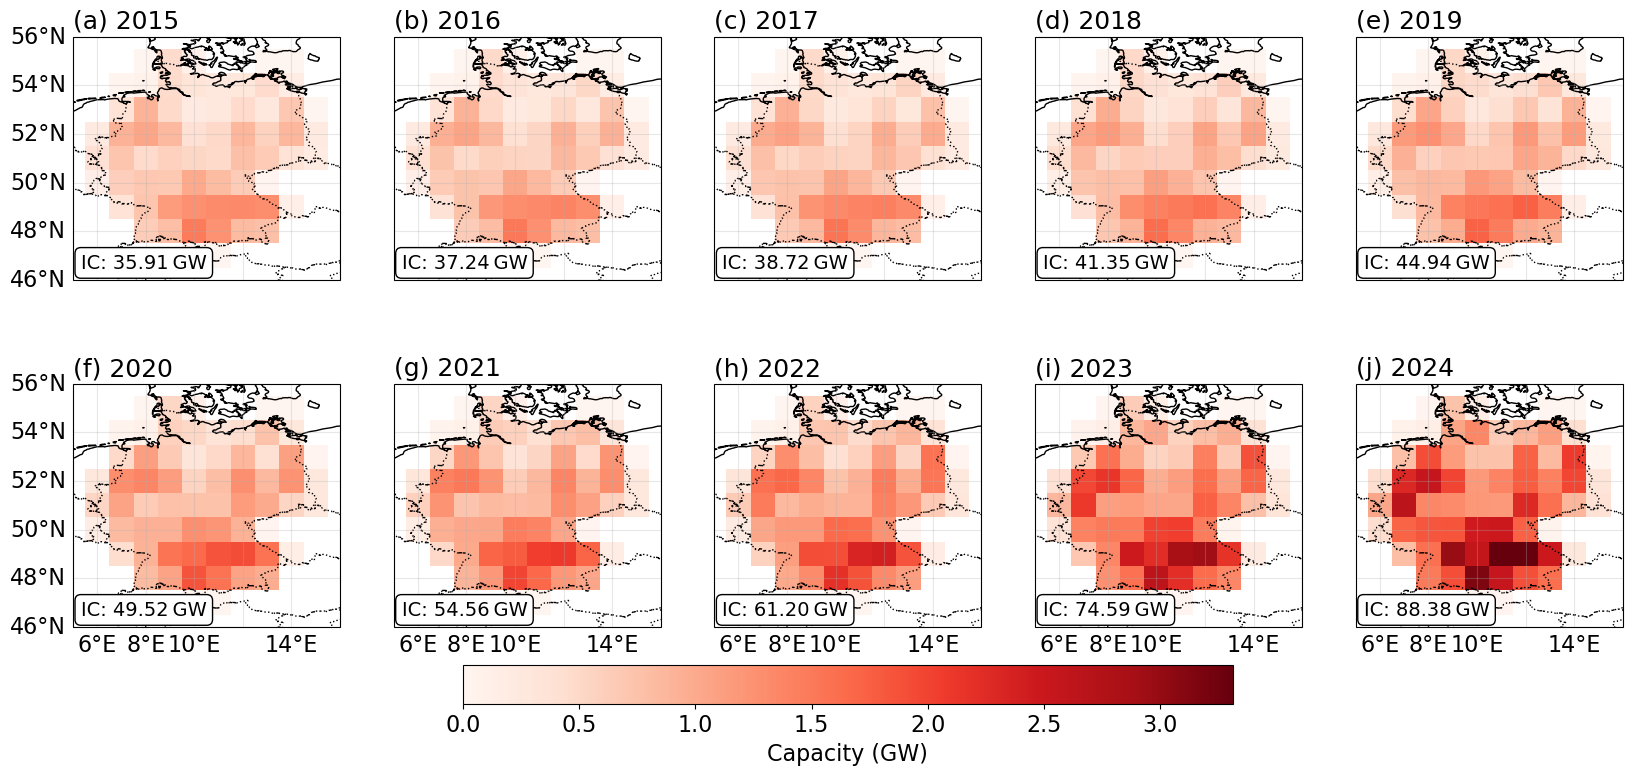

In [72]:
import matplotlib as mpl
import matplotlib.ticker as mticker
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()

fig, axes = plt.subplots(
    2, 5, figsize=(20, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'hspace': 0.003} 
)

axes = axes.flatten()

# axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
data = [xxx1, xxx2, xxx3, xxx4, xxx5, xxx6, xxx7, xxx8, xxx9, xxx10]
labels = ['(a) 2015', '(b) 2016', '(c) 2017', '(d) 2018', '(e) 2019', '(f) 2020', '(g) 2021', '(h) 2022', '(i) 2023', '(j) 2024']
capacities = [
    f"IC: {grid_2015_sum.values:.2f} GW",
    f"IC: {grid_2016_sum.values:.2f} GW",
    f"IC: {grid_2017_sum.values:.2f} GW",
    f"IC: {grid_2018_sum.values:.2f} GW",
    f"IC: {grid_2019_sum.values:.2f} GW",
    f"IC: {grid_2020_sum.values:.2f} GW",
    f"IC: {grid_2021_sum.values:.2f} GW",
    f"IC: {grid_2022_sum.values:.2f} GW",
    f"IC: {grid_2023_sum.values:.2f} GW",
    f"IC: {grid_2024_sum.values:.2f} GW",
]
label_sizes = {'title': 18, 'box': 14}

for ax, dat, lab, cap, ll, bl in zip(axes, data, labels, capacities, [True, False, False, False, False, True, False, False, False, False], [False, False, False, False, False, True, True, True, True, True]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )
    
    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, deg=2, alpha=0.3, ll=ll, bl=bl)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.05        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)')
cbar.ax.tick_params()
# Explicit ticks from 0.0 to 4.0 every 0.5
# ticks = np.arange(0.0, 4.0 + 0.5, 0.5)   # array([0. , 0.5, 1. , ..., 4. ])
# cbar.set_ticks(ticks)

# Force one decimal place on tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# plt.tight_layout()
# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()

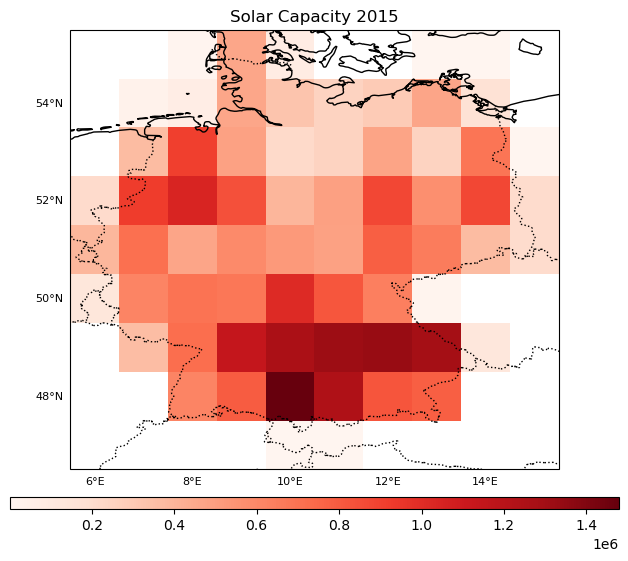

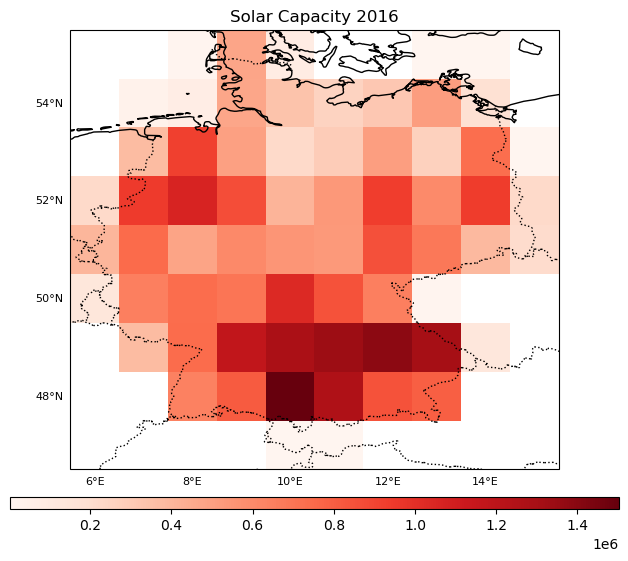

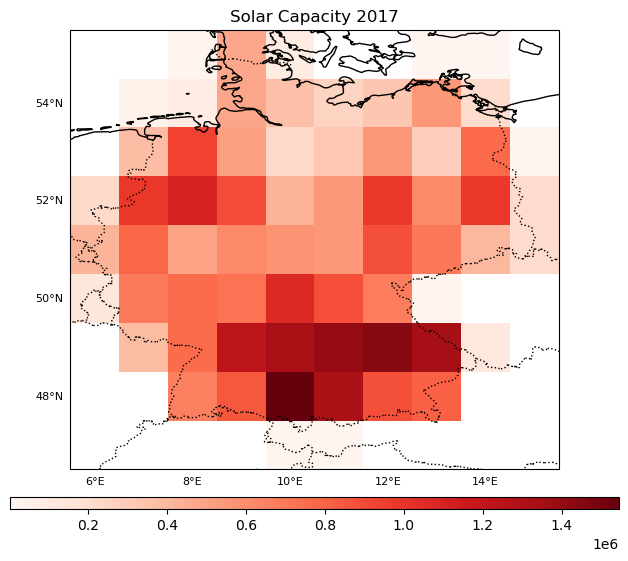

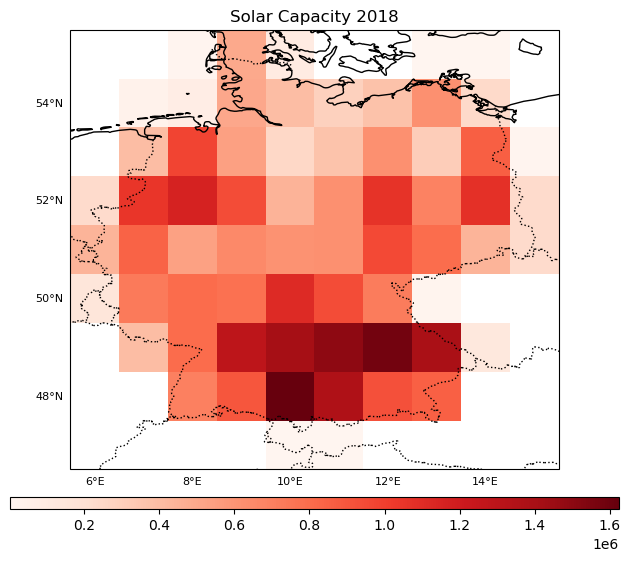

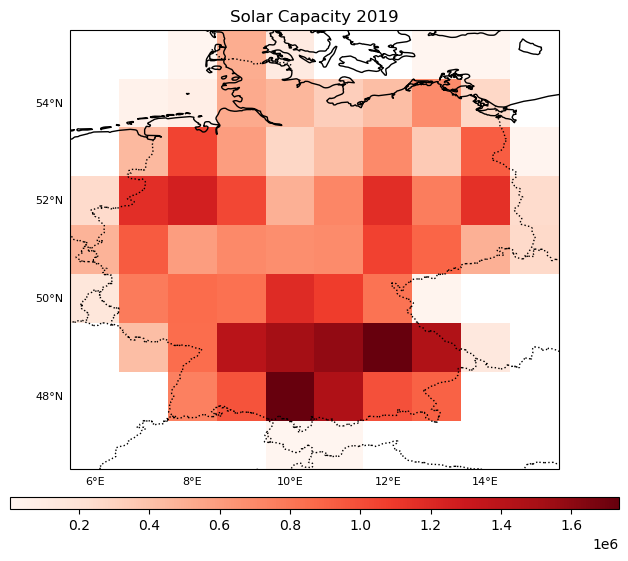

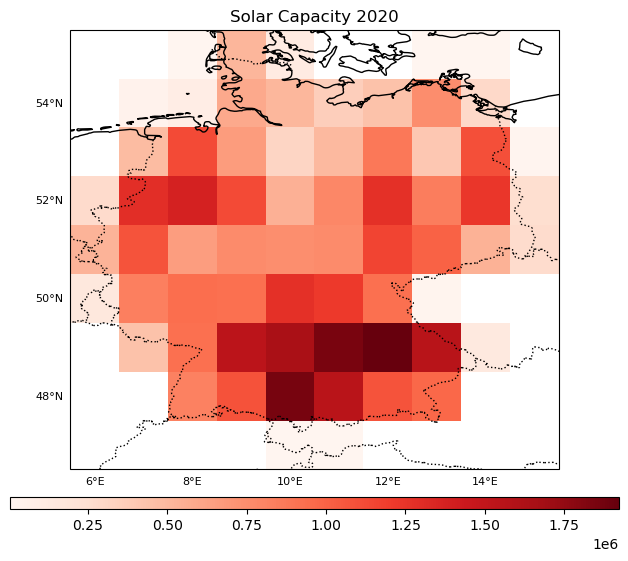

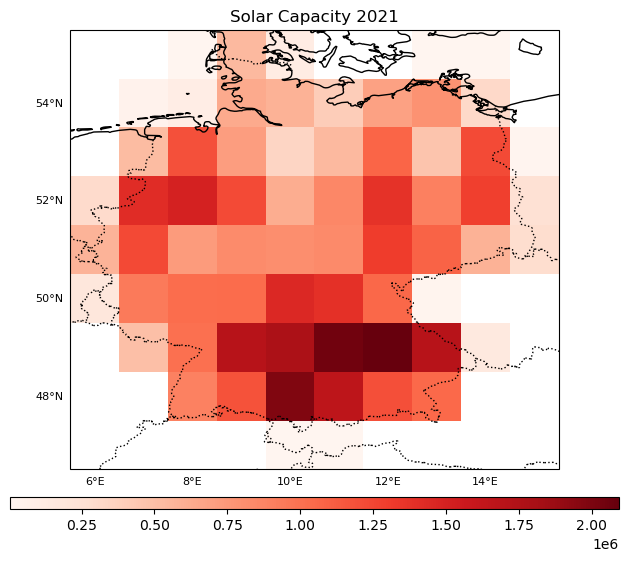

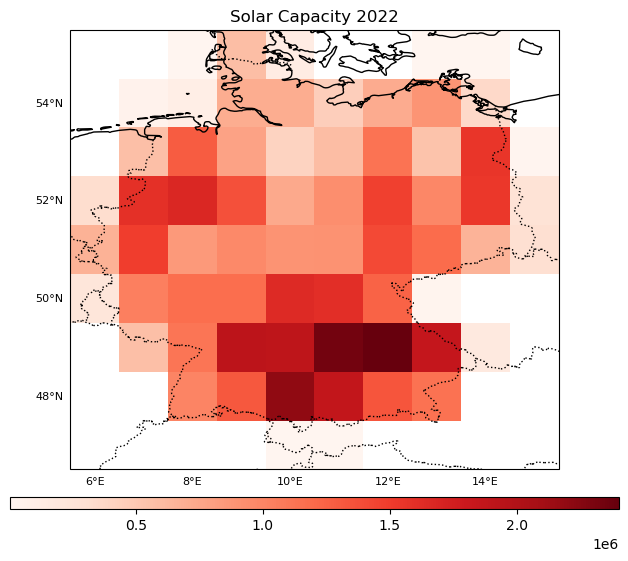

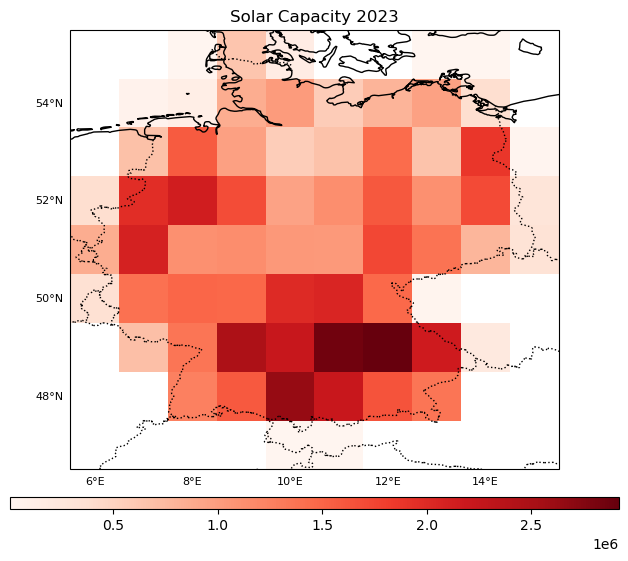

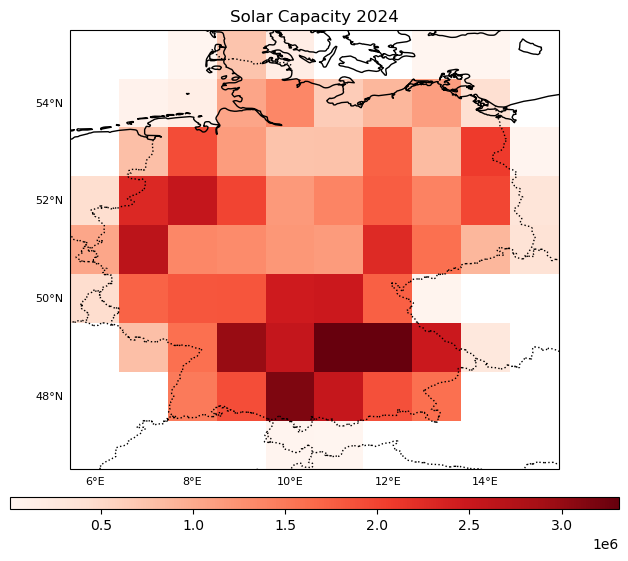

In [ ]:
for year in range(2015, 2025):
    grid = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_{year}.nc')
    
    lon_edges = grid.lon.values
    lat_edges = grid.lat.values

    # Plot the data

    fig = plt.figure(figsize=(9, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # First subplot
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    im = ax.pcolormesh(lon_edges, lat_edges, grid['solar_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(2)
    gl.ylocator = MultipleLocator(2)
    ax.set_title(f'Solar Capacity {year}')

    plt.tight_layout()
    plt.show()